# MNIST

In [2]:
import sys
import torch
from torch.utils.tensorboard import SummaryWriter

sys.path.append("..")

from utils.checkpoint import load_checkpoint
from utils.data import get_dataloaders

from models.lenet import Net
from config import Config


In [ ]:
config = Config()
device = config.device

writer = SummaryWriter(log_dir="../runs/mnist_uncertainties")

# Prepare data
_, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
)

# Model
model = Net(
    prior_sigma1=config.prior_sigma1,
    prior_sigma2=config.prior_sigma2,
    prior_pi=config.prior_pi,
    num_classes=config.num_classes,
).to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

# Load weights
config.model_name = 'mnist_bayesian_lenet_20251201'
epoch = load_checkpoint(model, optimizer, config.checkpoint_path, device)


[checkpoint] Loaded from ../checkpoints/mnist_bayesian_lenet_20251201.pth, starting at epoch 477


In [5]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from evaluate import evaluate_with_uncertainty

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform,
)
whole_loader = torch.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

output, uncertainties = evaluate_with_uncertainty(model, test_loader, device, mc_samples=5)

Predictions: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0]
Aleatoric: 0.015975981950759888
Epistemic: 0.0011583443265408278


### Images

In [6]:
def add_salt_pepper(img, amount):
    noise = torch.rand_like(img)
    img = img.clone()
    img[noise < amount/2] = 0
    img[noise > 1-amount/2] = 1
    return img

def gaussian_blur(img, kernel_size):
    from torchvision.transforms.functional import gaussian_blur
    return gaussian_blur(img, kernel_size)

def rotate(img, angle):
    from torchvision.transforms.functional import rotate
    return rotate(img, angle)

Random batch index: 454, image index: 5
Baseline uncertainties:
  Total: 0.0171
  Aleatoric: 0.0164
  Epistemic: 0.0007


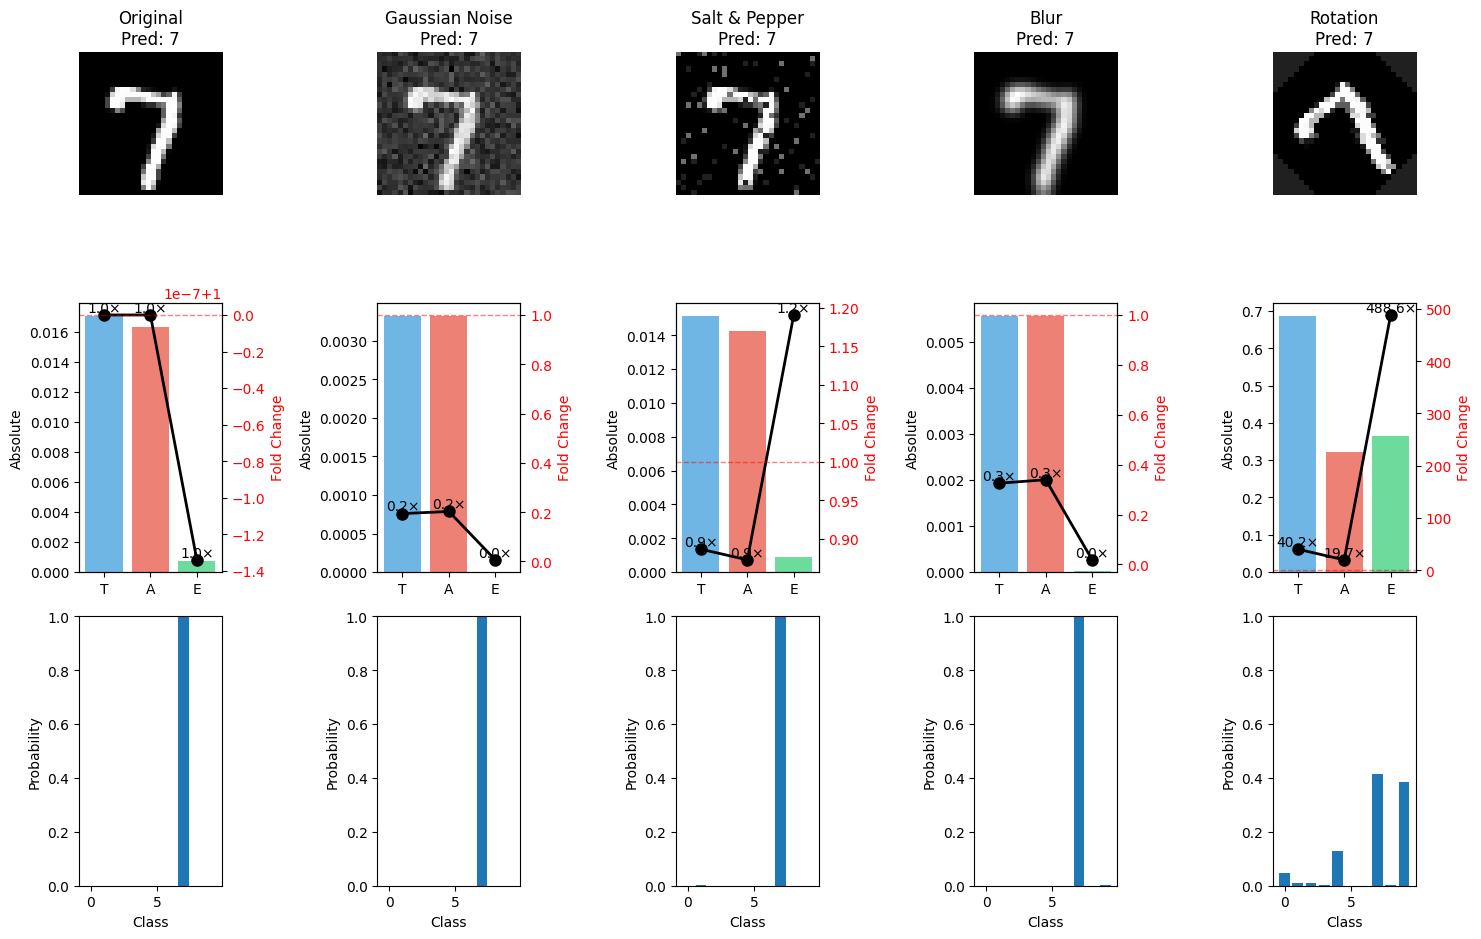

In [51]:
import random
from itertools import islice
import matplotlib.pyplot as plt
from utils.uncertainty import quantify_uncertainties, mc_predict

def test_on_corruptions(model, test_loader, device, batch_idx=0, img_idx=0):
    """Проверка на разных типах искажений"""
    
    img, label = next(islice(test_loader, batch_idx, batch_idx+1))
    img = img.to(device)
    
    fig, axes = plt.subplots(3, 5, figsize=(15, 10))
    
    corruptions = {
        'Original': lambda x: x,
        'Gaussian Noise': lambda x: x + torch.randn_like(x) * 0.3,
        'Salt & Pepper': lambda x: add_salt_pepper(x, 0.1),
        'Blur': lambda x: gaussian_blur(x, kernel_size=5),
        'Rotation': lambda x: rotate(x, 45),
    }
    
    # Сначала получаем baseline (оригинальные неопределенности)
    baseline_img = corruptions['Original'](img)
    baseline_pred, (baseline_total, baseline_alea, baseline_epis) = quantify_uncertainties(
        model, baseline_img, T=20
    )
    
    baseline_total_unc = torch.diagonal(baseline_total[0]).sum().item()
    baseline_alea_unc = torch.diagonal(baseline_alea[0]).sum().item()
    baseline_epis_unc = torch.diagonal(baseline_epis[0]).sum().item()
    
    print(f"Baseline uncertainties:")
    print(f"  Total: {baseline_total_unc:.4f}")
    print(f"  Aleatoric: {baseline_alea_unc:.4f}")
    print(f"  Epistemic: {baseline_epis_unc:.4f}")
    
    for col, (name, corrupt_fn) in enumerate(corruptions.items()):
        corrupted = corrupt_fn(img[img_idx]).unsqueeze(0)
        pred, (total, alea, epis) = (0, [0,0,0])
        if col > 0:
            pred, (total, alea, epis) = quantify_uncertainties(model, corrupted, T=20)
        else:
            pred, (total, alea, epis) = baseline_pred[img_idx], (baseline_total, baseline_alea, baseline_epis)
        
        # Скалярные значения
        total_unc = torch.diagonal(total[0]).sum().item()
        alea_unc = torch.diagonal(alea[0]).sum().item()
        epis_unc = torch.diagonal(epis[0]).sum().item()

        # Относительное изменение (fold change)
        total_ratio = total_unc / baseline_total_unc
        alea_ratio = alea_unc / baseline_alea_unc
        epis_ratio = epis_unc / (baseline_epis_unc + 1e-10)  # избегаем деления на 0
        
        # Изображение
        axes[0, col].imshow(corrupted.cpu().squeeze(), cmap='gray')
        axes[0, col].set_title(f'{name}\nPred: {pred.item()}')
        axes[0, col].axis('off')

        
        # Основная ось: абсолютные значения
        ax1 = axes[1, col]
        bars = ax1.bar(['T', 'A', 'E'], [total_unc, alea_unc, epis_unc],
                    color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.7)
        ax1.set_ylabel('Absolute', color='black')
        ax1.tick_params(axis='y', labelcolor='black')

        # Вторая ось: относительные значения
        ax2 = ax1.twinx()
        ax2.plot(['T', 'A', 'E'], [total_ratio, alea_ratio, epis_ratio],
                'ko-', linewidth=2, markersize=8, label='Fold change')
        ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.5)
        ax2.set_ylabel('Fold Change', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        # Аннотации
        for i, (label, ratio) in enumerate(zip(['T', 'A', 'E'], 
                                            [total_ratio, alea_ratio, epis_ratio])):
            ax2.text(i, ratio, f'{ratio:.1f}×', ha='center', va='bottom')
        
        
        # MC-предсказания
        mc_preds = mc_predict(model, corrupted, mc_samples=20)
        mean_probs = mc_preds.mean(dim=0)[0]
        
        axes[2, col].bar(range(10), mean_probs.cpu().numpy())
        axes[2, col].set_xlabel('Class')
        axes[2, col].set_ylabel('Probability')
        axes[2, col].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig(f'corruption/[{batch_idx}][{img_idx}]', dpi=150)
    plt.show()
    writer.add_figure(f'corruption/[{batch_idx}][{img_idx}]', figure=fig)

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
test_on_corruptions(model, test_loader, device, batch_idx=rand_batch_idx, img_idx=rand_img_idx)

Baseline uncertainties:
  Total: 0.0199
  Aleatoric: 0.0182
  Epistemic: 0.0017


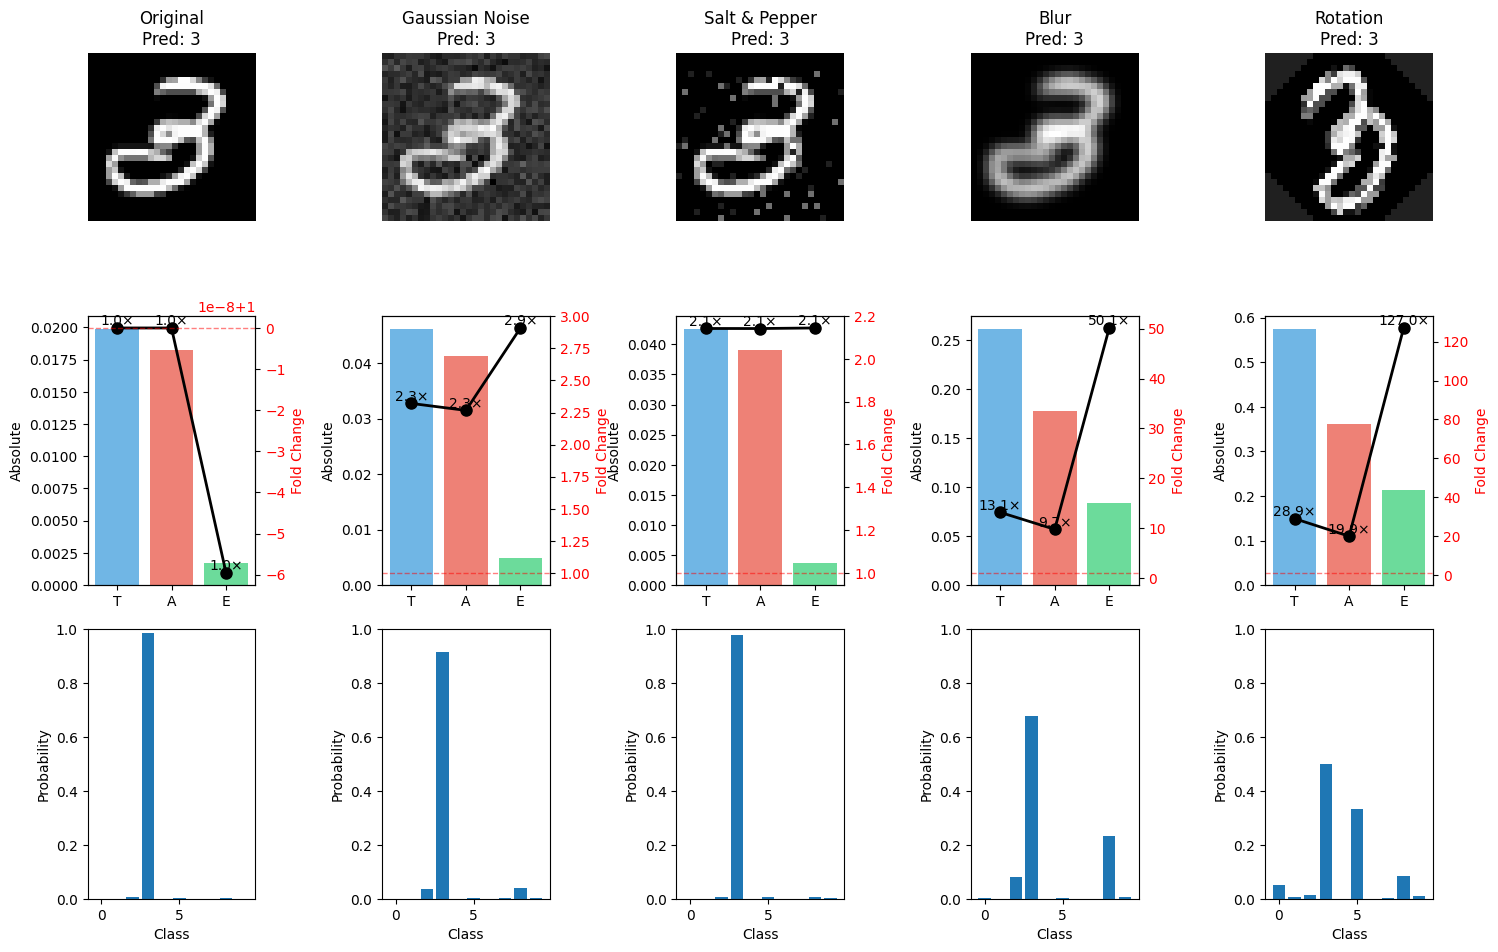

Baseline uncertainties:
  Total: 0.0101
  Aleatoric: 0.0099
  Epistemic: 0.0001


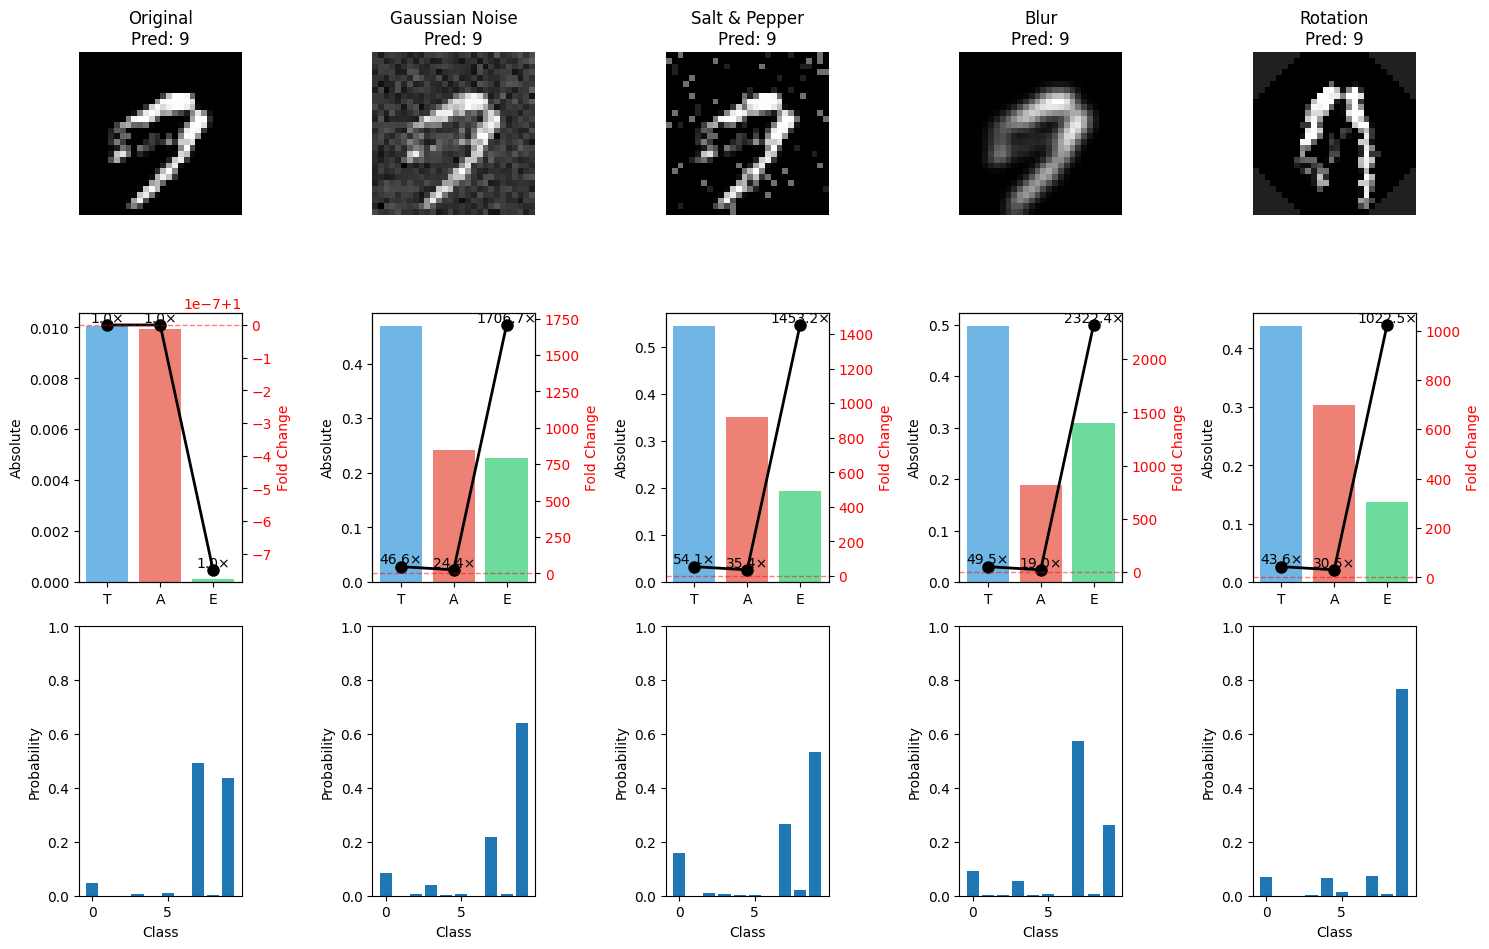

In [52]:
test_on_corruptions(model, test_loader, device, batch_idx=695, img_idx=12)
test_on_corruptions(model, test_loader, device, batch_idx=688, img_idx=10)

Baseline uncertainties:
  Total: 0.0181
  Aleatoric: 0.0177
  Epistemic: 0.0004


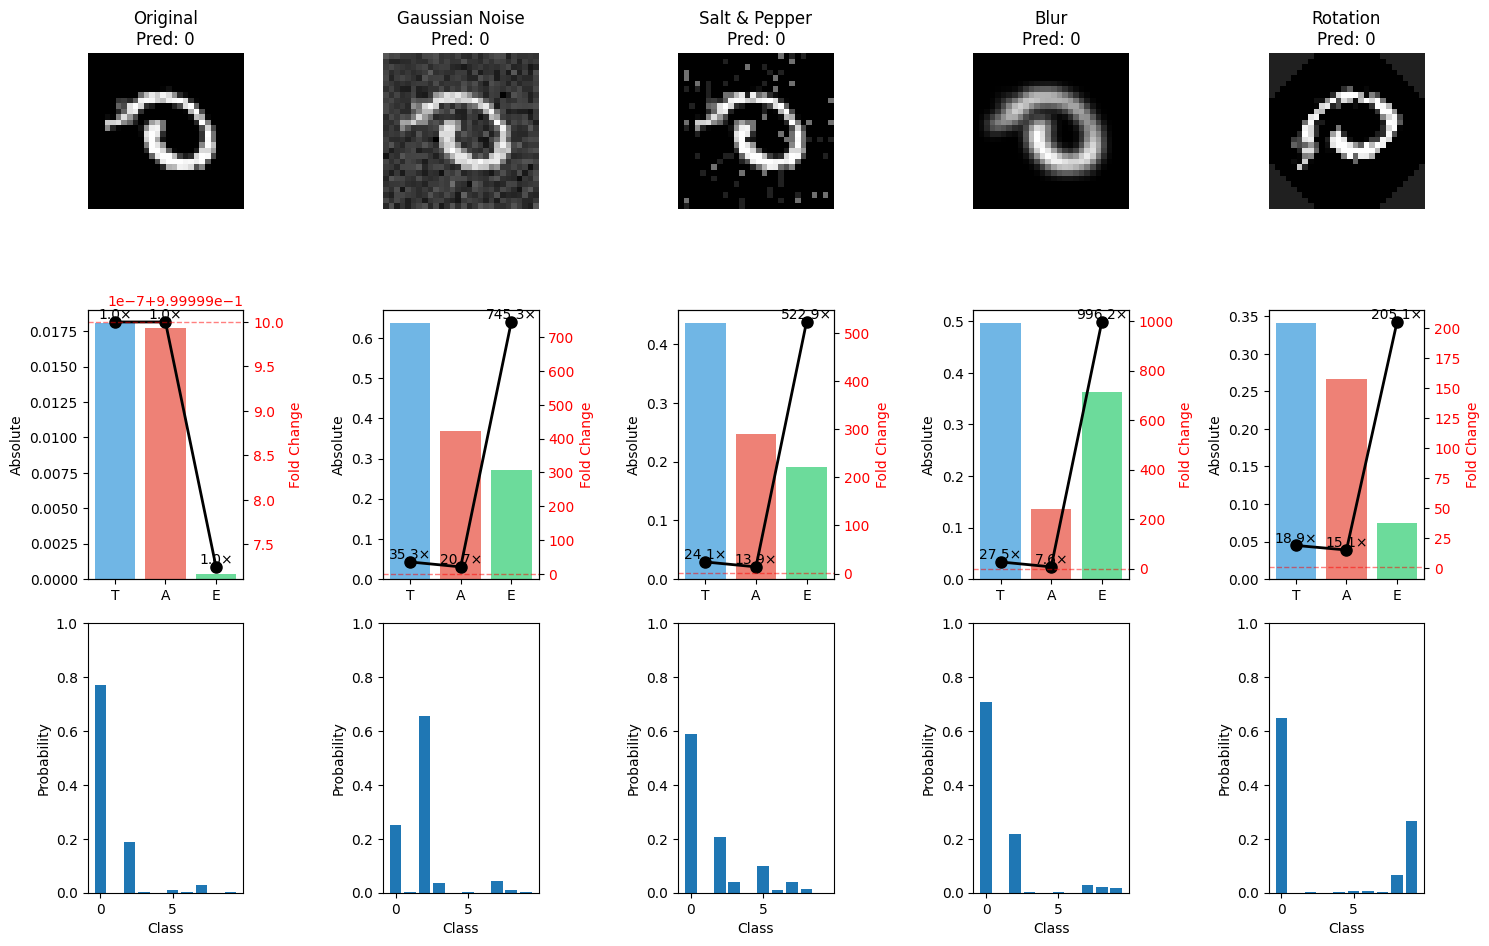

In [53]:
test_on_corruptions(model, test_loader, device, batch_idx=290, img_idx=5)